## Homework : Machine Learning Preparation

Nama : I Gusti Ngurah Agung Hari Vijaya Kusuma

Hobi : Push Rank

## Disclaimer saya berasumsi bahwa fitur exclusive merupakan label target pada dataset ini.

## `1. Descriptive Statistics (5 poin)`
Gunakan function info dan describe pada dataset ﬁnal project kalian. Tuliskan hasil observasinya, seperti:
- a. Apakah ada kolom dengan tipe data kurang sesuai, atau nama kolom dan isinya
kurang sesuai?
- b. Apakah ada kolom yang memiliki nilai kosong? Jika ada, apa saja?
- c. Apakah ada kolom yang memiliki nilai summary agak aneh? (min/mean/median/max/unique/top/freq)

 Untuk masing-masing jenis observasi, tuliskan juga jika tidak ada masalah, misal untuk A: “Semua tipe data sudah sesuai”


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler


agung = pd.read_csv(r'D:\rakamin_machinelearningprep\Homework\Product_Exclusive_Classification.csv')

agung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8000 non-null   int64  
 1   brand              8000 non-null   object 
 2   category           7987 non-null   object 
 3   rating             7905 non-null   float64
 4   number_of_reviews  7991 non-null   float64
 5   love               7966 non-null   float64
 6   price              7992 non-null   float64
 7   value_price        7983 non-null   float64
 8   exclusive          8000 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 562.6+ KB


In [2]:
agung.head(10)

,id,brand,category,rating,number_of_reviews,love,price,value_price,exclusive
0,50,SEPHORA COLLECTION,no category,5.0,46.0,0.0,50.0,50.0,0
1,304,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0
2,404,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0
3,443,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0
4,463,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0
5,6528,Givenchy,Perfume,4.5,94.0,3000.0,78.0,78.0,0
6,7393,BVLGARI,Cologne,5.0,31.0,3300.0,94.0,94.0,0
7,7740,Yves Saint Laurent,Perfume,4.5,164.0,4200.0,62.0,62.0,0
8,11023,Carolina Herrera,Perfume,4.5,127.0,2900.0,86.0,86.0,0
9,12104,Estée Lauder,Perfume,5.0,20.0,2200.0,85.0,85.0,0


In [3]:
agung.isnull().sum()

id                    0
brand                 0
category             13
rating               95
number_of_reviews     9
love                 34
price                 8
value_price          17
exclusive             0
dtype: int64

In [4]:
agung.describe()

,id,rating,number_of_reviews,love,price,value_price,exclusive
count,8.000000e+03,7905.000000,7991.000000,7.966000e+03,7992.000000,7983.000000,8000.000000
mean,1.910231e+06,4.085136,303.574396,1.756396e+04,49.900935,50.983300,0.255875
std,3.858353e+05,0.761069,931.724460,4.425339e+04,46.864764,48.473049,0.436379
min,5.000000e+01,0.000000,0.000000,0.000000e+00,2.000000,2.000000,0.000000
25%,1.773379e+06,4.000000,14.000000,2.000000e+03,24.000000,24.000000,0.000000
50%,2.030360e+06,4.000000,56.000000,5.500000e+03,35.000000,35.000000,0.000000
75%,2.185074e+06,4.500000,231.500000,1.530000e+04,59.000000,60.000000,1.000000
max,2.293801e+06,5.000000,19000.000000,1.300000e+06,549.000000,549.000000,1.000000


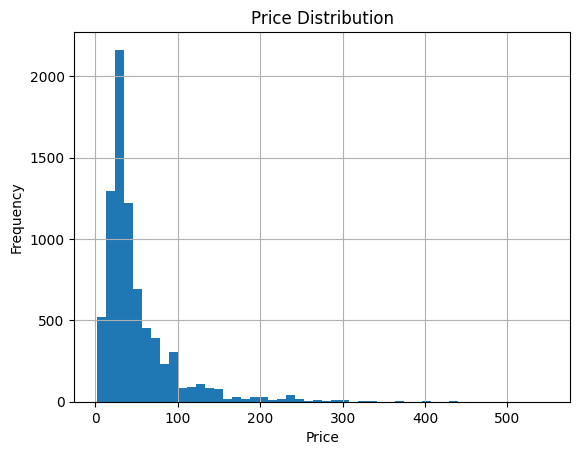

In [5]:
agung['price'].hist(bins=50)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

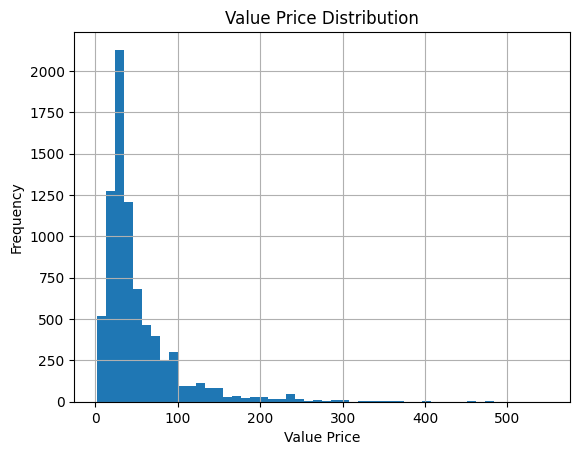

In [6]:
agung['value_price'].hist(bins=50)
plt.title('Value Price Distribution')
plt.xlabel('Value Price')
plt.ylabel('Frequency')
plt.show()

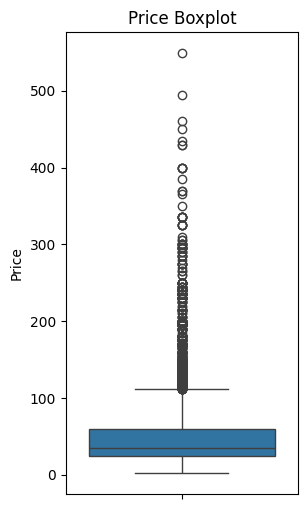

In [7]:
plt.figure(figsize=(3, 6))
sns.boxplot(y=agung['price'])
plt.title('Price Boxplot')
plt.ylabel('Price')
plt.show()

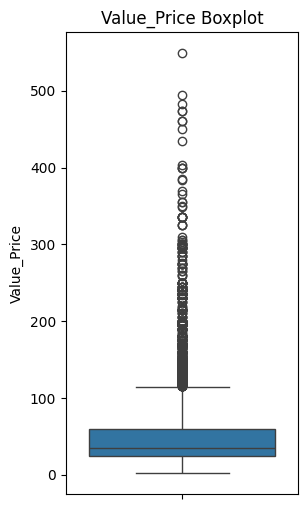

In [8]:
plt.figure(figsize=(3, 6))
sns.boxplot(y=agung['value_price'])
plt.title('Value_Price Boxplot')
plt.ylabel('Value_Price')
plt.show()

---

## *Interpretasi*

`A`. Semua fitur sudah memiliki tipe data yang sesuai menurut saya. 

`B`. Beberapa kolom memiliki nilai yang kosong/null. setelah melakukan df.isnull().sum() saya menemukan bahwa terdapat beberapa kolom yang memilki nilai null diantaranya:

- Kolom category = memiliki 13 baris yang kosong
- Kolom rating = memiliki 95 baris yang kosong
- kolom number_of_reviews = memiliki 9 baris yang kosong
- kolom love = memiliki 34 baris yang kosong
- kolom price = memiliki 8 baris yang kosong
- kolom value_price = memiliki 17 baris yang kosong

Dengan mengetahui kolom yang bernilai kosong ini, kita bisa mengisinya dengan nilai median, rata rata dll

`C`. Ya beberapa kolom memiliki tipe distribusi yang tidak normal atau skewed, dan hal tersebut mengindikasikan bahwa fitur/kolom tersebut memiliki nilai outlier terutama untuk kolom price dan value_price.

- Dari analisa yang telah dilakukan didapatkan bahwa kedua kolom tersebut memiliki nilai mean yang lebih besar dari median, serta juga sudah dicek dengan menggunakan histogram dan boxplot. kita mendapatkan bahwa tipe distribusinya adalah `postive skewed`



---

## `2. Univariate Analysis (10 poin)`
Gunakan visualisasi untuk melihat distribusi masing-masing kolom (feature maupun target). Tuliskan hasil observasinya, <br> misalnya jika ada suatu kolom yang distribusinya menarik (misal skewed, bimodal, ada outlier, ada nilai yang mendominasi, kategorinya terlalu banyak, dsb). <br>Jelaskan juga apa yang harus di-follow up saat data pre-processing.


In [9]:
agung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8000 non-null   int64  
 1   brand              8000 non-null   object 
 2   category           7987 non-null   object 
 3   rating             7905 non-null   float64
 4   number_of_reviews  7991 non-null   float64
 5   love               7966 non-null   float64
 6   price              7992 non-null   float64
 7   value_price        7983 non-null   float64
 8   exclusive          8000 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 562.6+ KB


In [10]:
numeric_cols = agung.select_dtypes(include=['float64', 'int64']).columns

In [11]:
numeric_cols_gemeter = numeric_cols.drop(['id', 'exclusive'])

In [12]:
n_cols = 3
n_rows = -(-len(numeric_cols_gemeter) // n_cols) 

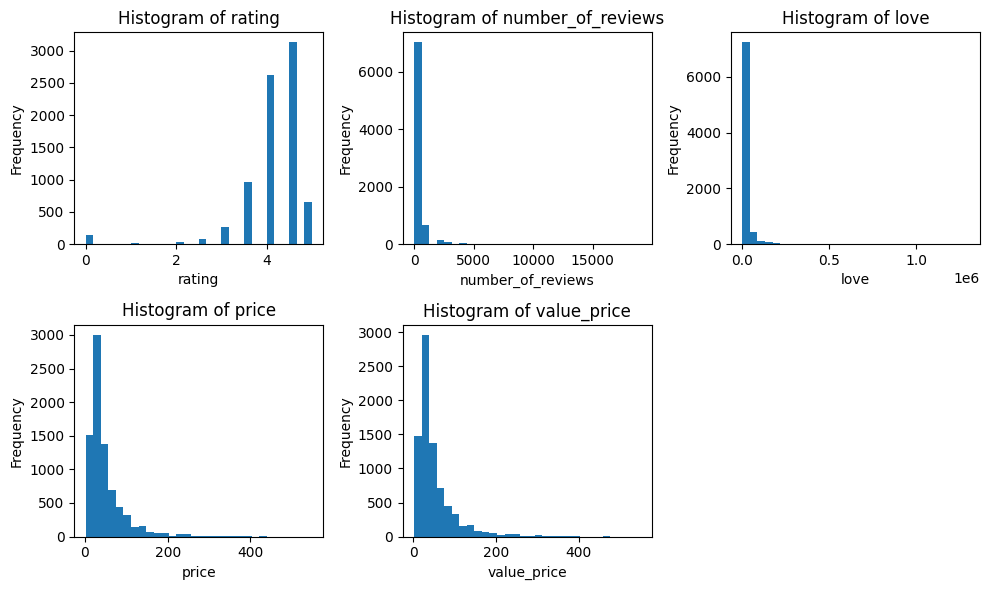

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_gemeter):
    axes[i].hist(agung[col].dropna(), bins=30)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

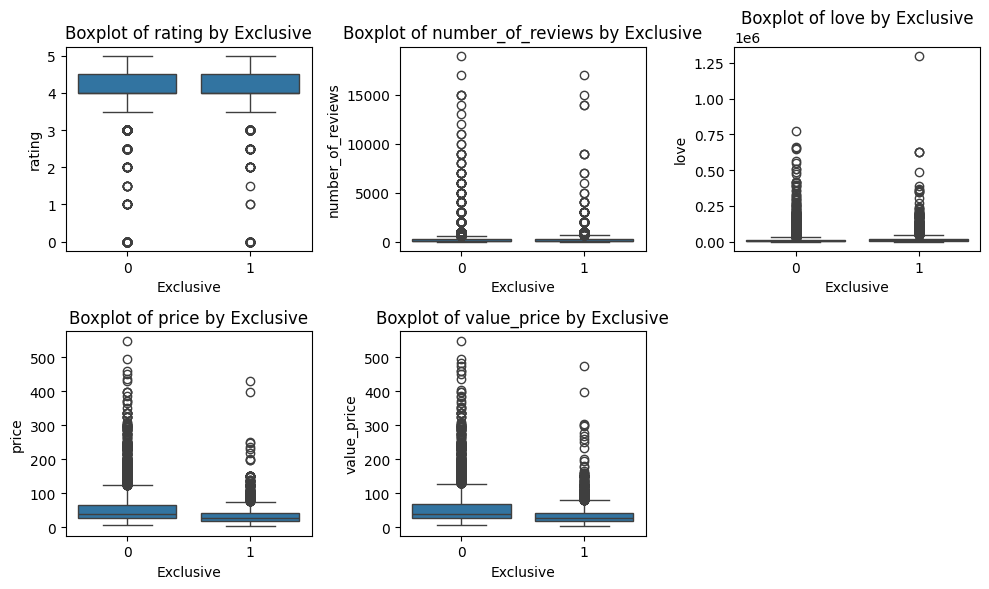

In [14]:
#boxplot untuk tiap kolom berdasarkan exclusive atau tidak exclusive
plt.figure(figsize=(10, 6))
for i, col in enumerate(numeric_cols_gemeter):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='exclusive', y=col, data=agung)
    plt.title(f'Boxplot of {col} by Exclusive')
    plt.xlabel('Exclusive')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [15]:
mantap = agung.groupby('exclusive')[numeric_cols_gemeter].describe()
print(mantap.info())


<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 0 to 1
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   (rating, count)             2 non-null      float64
 1   (rating, mean)              2 non-null      float64
 2   (rating, std)               2 non-null      float64
 3   (rating, min)               2 non-null      float64
 4   (rating, 25%)               2 non-null      float64
 5   (rating, 50%)               2 non-null      float64
 6   (rating, 75%)               2 non-null      float64
 7   (rating, max)               2 non-null      float64
 8   (number_of_reviews, count)  2 non-null      float64
 9   (number_of_reviews, mean)   2 non-null      float64
 10  (number_of_reviews, std)    2 non-null      float64
 11  (number_of_reviews, min)    2 non-null      float64
 12  (number_of_reviews, 25%)    2 non-null      float64
 13  (number_of_reviews, 50%)    2 non-null      

In [16]:
print(mantap['rating'])

            count      mean       std  min  25%  50%  75%  max
exclusive                                                     
0          5864.0  4.092002  0.752857  0.0  4.0  4.0  4.5  5.0
1          2041.0  4.065409  0.784037  0.0  4.0  4.0  4.5  5.0


In [17]:
print(mantap['number_of_reviews'])

            count        mean         std  min   25%   50%    75%      max
exclusive                                                                 
0          5944.0  300.667900  933.311984  0.0  13.0  54.0  224.0  19000.0
1          2047.0  312.014167  927.274919  0.0  17.0  59.0  263.0  17000.0


In [18]:
print(mantap['love'])

            count          mean           std  min     25%     50%      75%  \
exclusive                                                                     
0          5920.0  16152.834797  40602.334623  0.0  1800.0  5000.0  13800.0   
1          2046.0  21646.977028  53231.498567  0.0  2600.0  7300.0  20775.0   

                 max  
exclusive             
0           770700.0  
1          1300000.0  


In [19]:
print(mantap['price'])

            count       mean        std  min   25%   50%   75%    max
exclusive                                                            
0          5946.0  54.986076  50.462080  4.9  26.0  38.0  65.0  549.0
1          2046.0  35.122708  29.763636  2.0  18.0  28.0  41.0  429.0


In [20]:
print(mantap['value_price'])

            count       mean        std  min   25%   50%   75%    max
exclusive                                                            
0          5937.0  55.802124  51.764772  4.9  26.0  38.0  67.0  549.0
1          2046.0  37.000230  33.615346  2.0  19.0  28.0  43.0  474.0


---



## *Interpretasi*

Semua kolom yang memiliki tipe numerik dikelompokan untuk di cek tipe distribusinya.

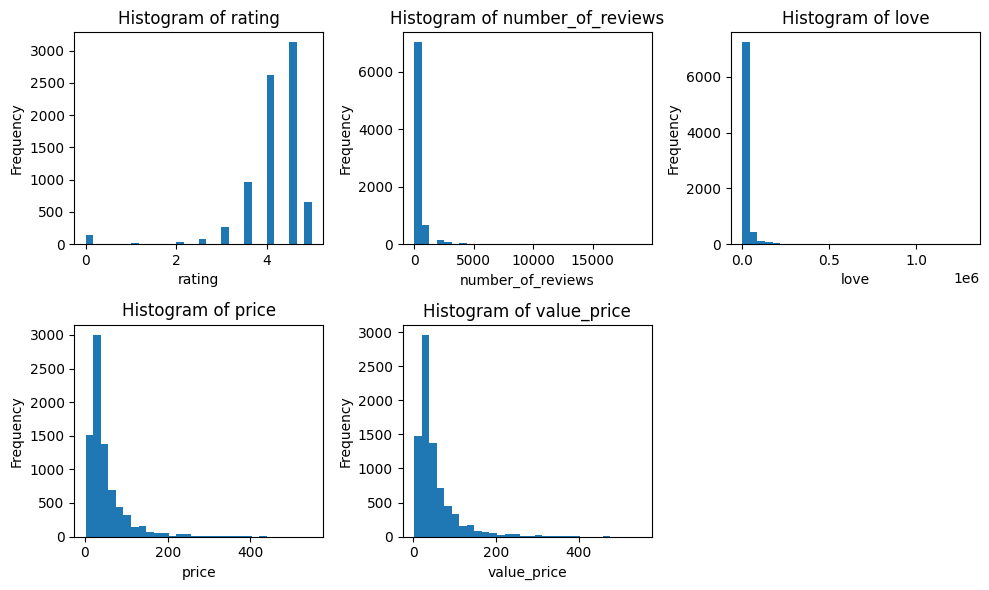

Dari plot berikut didapatkan bahwa
- Kolom rating memiliki tipe distribusi negative skewed, dibuktikan dari histogram yang cendrung miring kiri dan nilai median yang lebih besar dari mean dengan nilai sebagai berikut.
- Kolom number_of_review memiliki tipe distribusi positive skewed, dibuktikan dari histogram yang cendrung miring ke kanan dan nilai mean yang lebih besar dari median dengan nilai sebagai berikut.
- Kolom love memiliki tipe distribusi positive skewed, dibuktikan darii histogram yang cendrung miring kanan dan nilai mean lebih besar dari median dengan nilai sebagai berikut
- kolom price memiliki tipe distribusi positive skewed, dibuktikan dari histogram yang cendrung miring kanan dan nilai mean lebih besar dari median dengan nilai sebagai berikut
- kolom value_price memilki tipe distribusi positive skewed, dibuktikan dari histogram yang cendrung miring kanan dan nilai mean lebih besar dari median dengan nilai sebagai berikut

Dari interpretasi tersebut kita mendapatkan bahwa hampir semua kolom yang bertipe numerik memiliki tipe distribusi skewed, yang menandakan bahwa besar kemungkinan kolom kolom memiliki nilai outlier. Dan untuk mengetahui outlier tersebut, maka dicari nilai IQR pada masing masing fitur yang bertujuan untuk mengetahui nilai mana yang sudah termasuk outlier

Upper Bound dan lower Bound pada masing masing kolom :

- rating, lower bound, upper bound (np.float64(3.25), np.float64(5.25))

- price, lower bound, upper bound (np.float64(-28.5), np.float64(111.5))

- value_price, lower bound, upper bound (np.float64(-30.0), np.float64(114.0))

- number_of_review, lower bound, upper bound (np.float64(-312.25), np.float64(557.75))

- love, lower bound, upper bound (np.float64(-17950.0), np.float64(35250.0))

Dengan mengetahui ambang batas tersebut bisa dilakukan penanganan outlier dengan melakukan transofrm log untuk kolom yang skewed.

Setelah mengetahui karakter distribusi secara keseluruhan, dilakukan analisis statistik deskriptif berdasarkan label target (exclusive) untuk menilai apakah distribusi fitur numerik berbeda signifikan antara kedua kelas.

Kolom Rating :

```
           count      mean       std  min  25%  50%  75%  max
exclusive                                                     
0          5864.0  4.092002  0.752857  0.0  4.0  4.0  4.5  5.0
1          2041.0  4.065409  0.784037  0.0  4.0  4.0  4.5  5.0
```

Kolom number_of_review :

```
          count        mean         std  min   25%   50%    75%      max
exclusive                                                                 
0          5944.0  300.667900  933.311984  0.0  13.0  54.0  224.0  19000.0
1          2047.0  312.014167  927.274919  0.0  17.0  59.0  263.0  17000.0
```

Kolom love :
```
           count          mean           std  min     25%     50%      75%     max  
exclusive                                                                     
0          5920.0  16152.834797  40602.334623  0.0  1800.0  5000.0  13800.0   770700.0 
1          2046.0  21646.977028  53231.498567  0.0  2600.0  7300.0  20775.0   1300000.0 
```

Kolom price :
```
           count       mean        std  min   25%   50%   75%    max
exclusive                                                            
0          5946.0  54.986076  50.462080  4.9  26.0  38.0  65.0  549.0
1          2046.0  35.122708  29.763636  2.0  18.0  28.0  41.0  429.0
```

Kolom value_price :
```
           count       mean        std  min   25%   50%   75%    max
exclusive                                                            
0          5937.0  55.802124  51.764772  4.9  26.0  38.0  67.0  549.0
1          2046.0  37.000230  33.615346  2.0  19.0  28.0  43.0  474.0
```

Ditampilkan juga boxplot untuk mengecek outlier

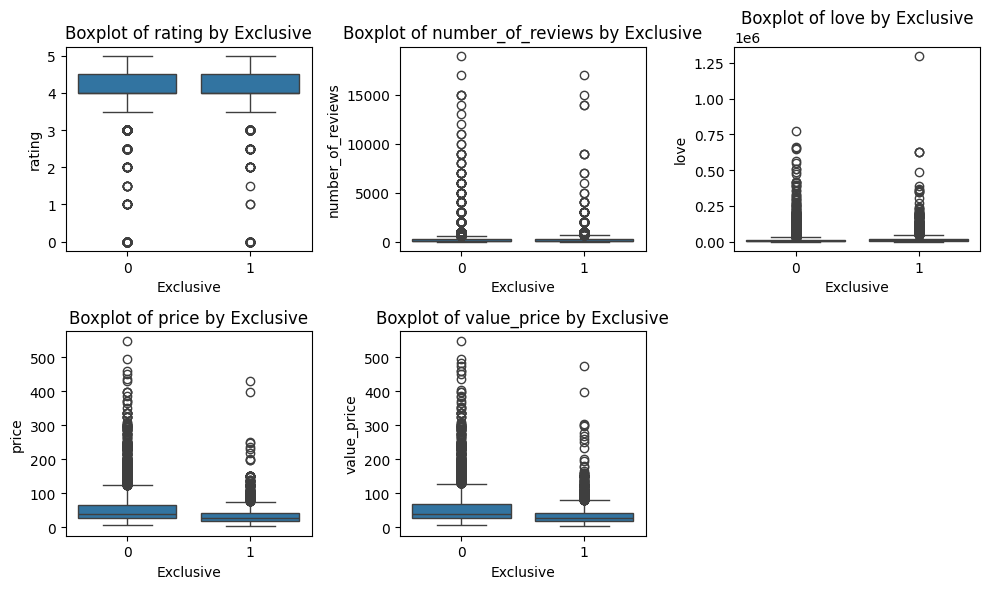

Dari masing masing fitur hampir semua memiliki distribusi positive skewed terutama untuk fitur yang memiliki nilai mean > median(Q2), dan karena outlier menarik nilai mean maka nilai median lebih representatif dalam analisa kali ini.

Sehingga , dengan membandingkan nilai median yaitu dari Q2 (Ini didasari atas boxplot yang menunjukan banyak outlier). Ditemukan bahwa hampir semua fitur numerik tidak memiliki perbedaan distribusi yang signifikan antara produk exclusive dan non exclusive. Nilai rating, jumlah review, dan jumlah love antara kedua kelas sangat mirip, meskipun produk exclusive sedikit lebih banyak dilove dan direview. Uniknya, produk exclusive dalam dataset ini justru memiliki harga dan value price yang lebih rendah dibandingkan produk non exclusive. Temuan ini menunjukkan bahwa fitur fitur numerik pada dataset ini tidak memiliki daya pisah yang kuat terhadap label exclusive

---

## 3. Multivariate Analysis (15 poin)

Lakukan multivariate analysis (seperti correlation heatmap dan category plots, sesuai yang diajarkan di kelas). Tuliskan hasil observasinya, seperti:
- Bagaimana korelasi antara masing-masing feature dan label. Kira-kira feature mana saja yang paling relevan dan harus dipertahankan?
-  Bagaimana korelasi antar-feature, apakah ada pola yang menarik? Apa yang perlu dilakukan terhadap feature itu?

Tuliskan juga jika memang tidak ada feature yang saling berkorelasi


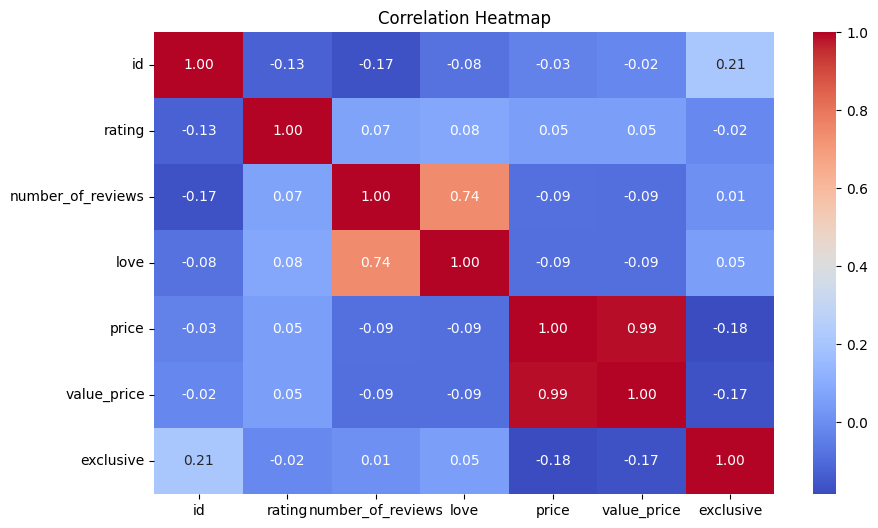

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(agung[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
brand_exclusive = pd.crosstab(agung['brand'], agung['exclusive'], normalize='index')
print(brand_exclusive)

exclusive                0         1
brand                               
8Greens           1.000000  0.000000
AERIN             1.000000  0.000000
ALTERNA Haircare  0.952381  0.047619
AMOREPACIFIC      0.903226  0.096774
Acqua Di Parma    0.961538  0.038462
...                    ...       ...
shu uemura        1.000000  0.000000
stila             1.000000  0.000000
surratt beauty    0.880000  0.120000
tarte             0.713287  0.286713
trèStiQue         0.500000  0.500000

[310 rows x 2 columns]


In [23]:
category_exclusive = pd.crosstab(agung['category'], agung['exclusive'], normalize='index')
print(category_exclusive)


exclusive                        0         1
category                                    
Accessories               0.000000  1.000000
After Sun Care            1.000000  0.000000
Aftershave                1.000000  0.000000
Anti-Aging                0.861111  0.138889
BB & CC Cream             0.944444  0.055556
...                            ...       ...
Tinted Moisturizer        0.857143  0.142857
Toners                    0.780488  0.219512
Tweezers & Eyebrow Tools  0.416667  0.583333
Value & Gift Sets         0.580913  0.419087
no category               0.866667  0.133333

[142 rows x 2 columns]


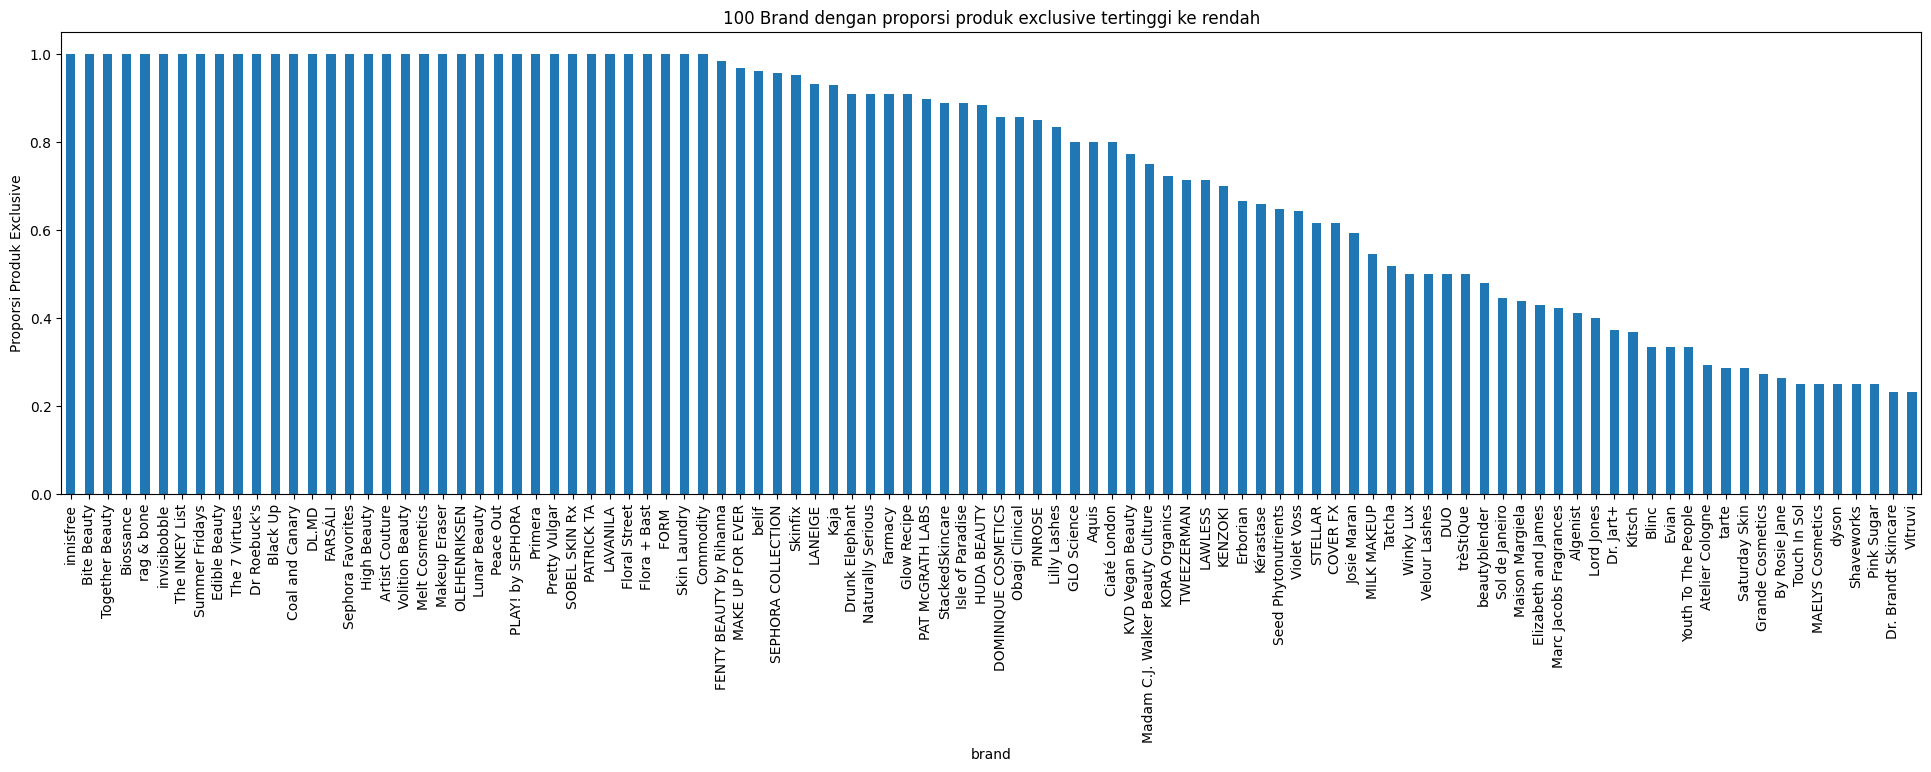

In [24]:
brand_prop = agung.groupby('brand')['exclusive'].mean().sort_values(ascending=False)

plt.figure(figsize=(24, 6))
brand_prop.head(100).plot(kind='bar')
plt.ylabel('Proporsi Produk Exclusive')
plt.title('100 Brand dengan proporsi produk exclusive tertinggi ke rendah')
plt.show()


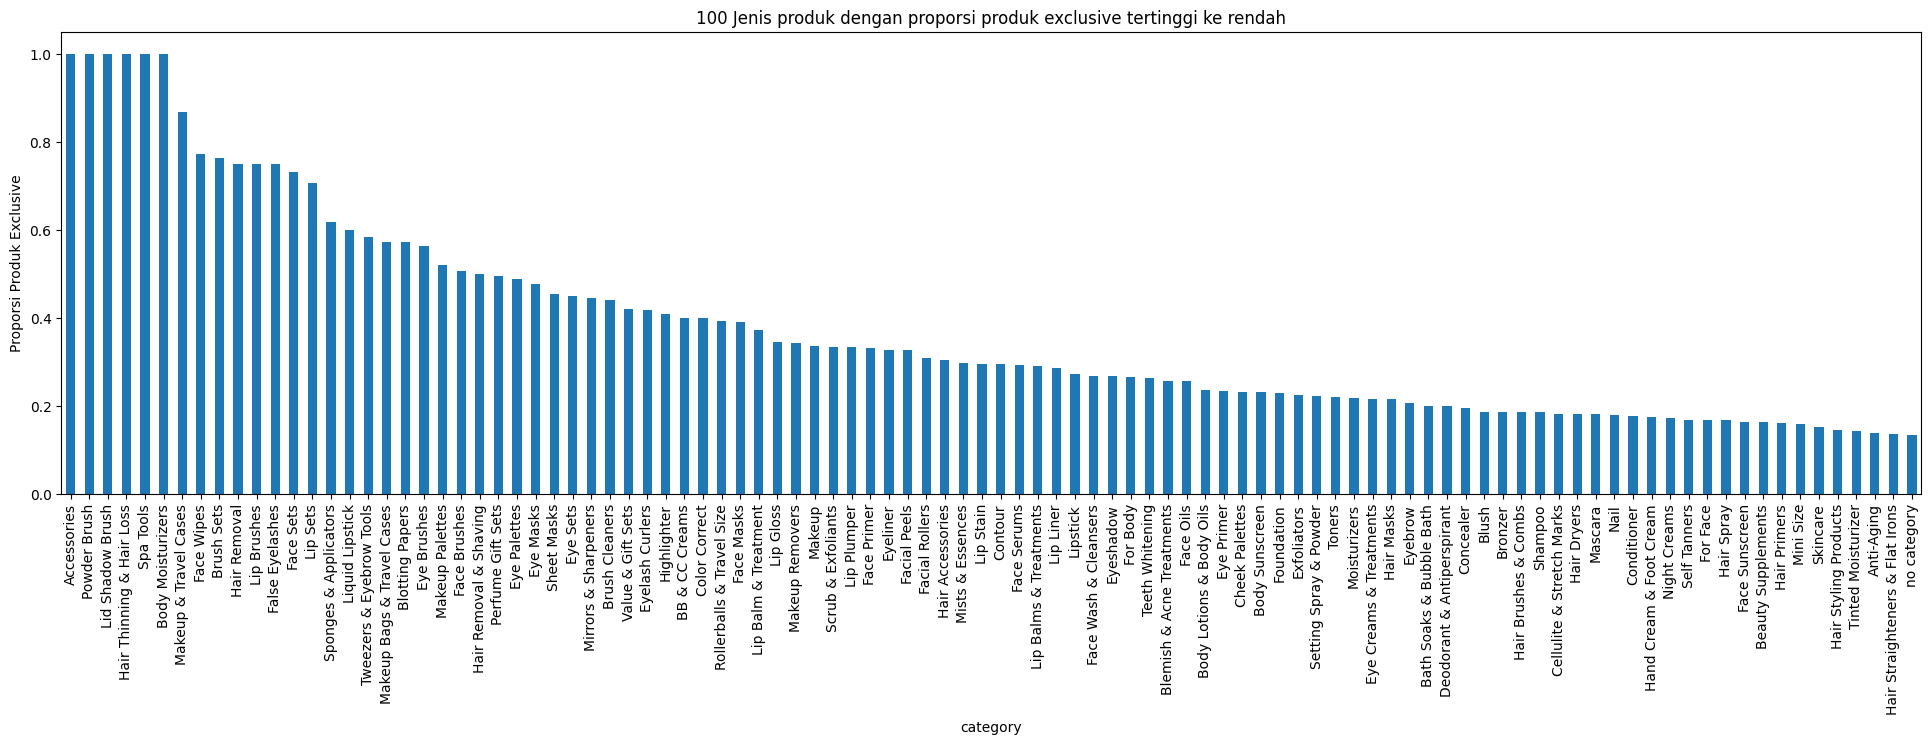

In [25]:
brand_prop = agung.groupby('category')['exclusive'].mean().sort_values(ascending=False)

plt.figure(figsize=(24, 6))
brand_prop.head(100).plot(kind='bar')
plt.ylabel('Proporsi Produk Exclusive')
plt.title('100 Jenis produk dengan proporsi produk exclusive tertinggi ke rendah')
plt.show()


---

## *Interpretasi*

Heatmap korelasi digunakan untuk mengetahui sejauh mana hubungan linear antara fitur numerik dalam dataset.

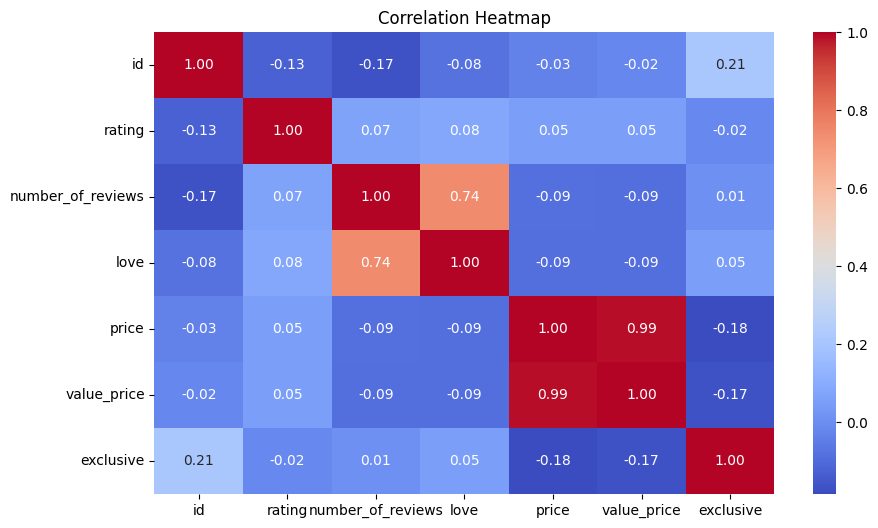

(Disclaimer saya berasumsi bahwa fitur exclusive merupakan label target pada dataset ini.)

- Kolom price dan value_price memiliki korelasi yang sangat kuat yaitu 0.99 yang artinya informasi yang dibawa keduanya hampir sama. Ini masuk akal mengingat kolom price adalah kolom yang berisi data harga setelah diskon dan kolom value_price adalah kolom yang berisi data harga asli. Dari hasil ini saya menyarankan menggunakan value_price mengingat merupakan harga asli produk.

- Kolom id hanya penanda unik setiap baris produk, tidak memiliki informasi prediktif. Sehingga wajib untuk kita drop

- korelasi kuat positif antara fitur number_of_review dan love, tidak perlu di drop karena logika aja contoh : Produk dengan love tinggi tapi review sedikit = viral, tapi belum tentu trusted (pemutih abal abal, bisa putih dalam 15 menit). Produk dengan review tinggi tapi love sedikit = banyak transaksi, tapi kurang disukai (artinya produknya fungsionalitas tinggi, atau mungkin udah mainstream aja contoh vaseline sunscreen).

- Setelah dilakukan eksplorasi dan analisis korelasi, ditemukan bahwa label target exclusive tidak memiliki hubungan yang kuat dengan fitur-fitur yang tersedia. Hal ini mengindikasikan bahwa status exclusive kemungkinan ditentukan secara acak, subjektif, atau berdasarkan faktor yang tidak terekam dalam dataset. Namun bisa saja label exclusive ini justru berkorelasi (atau setidaknya lebih terhubung) dengan fitur kategorikal seperti brand atau category, bukan fitur numerik. Dan karena saya kurang paham kosmetik jadi saya agak bingung

- Selain pasangan fitur yang disebutkan di atas, hubungan antar fitur numerik lainnya seluruhnya lemah, sehingga tidak ada multikolinearitas atau redundansi yang berarti di antara mereka.


selanjutnya kita akan melakukan eksplorasi lebih lanjut pada fitur kategorikal (brand dan category) untuk melihat kemungkinan adanya pola tersembunyi yang mempengaruhi status exclusive.


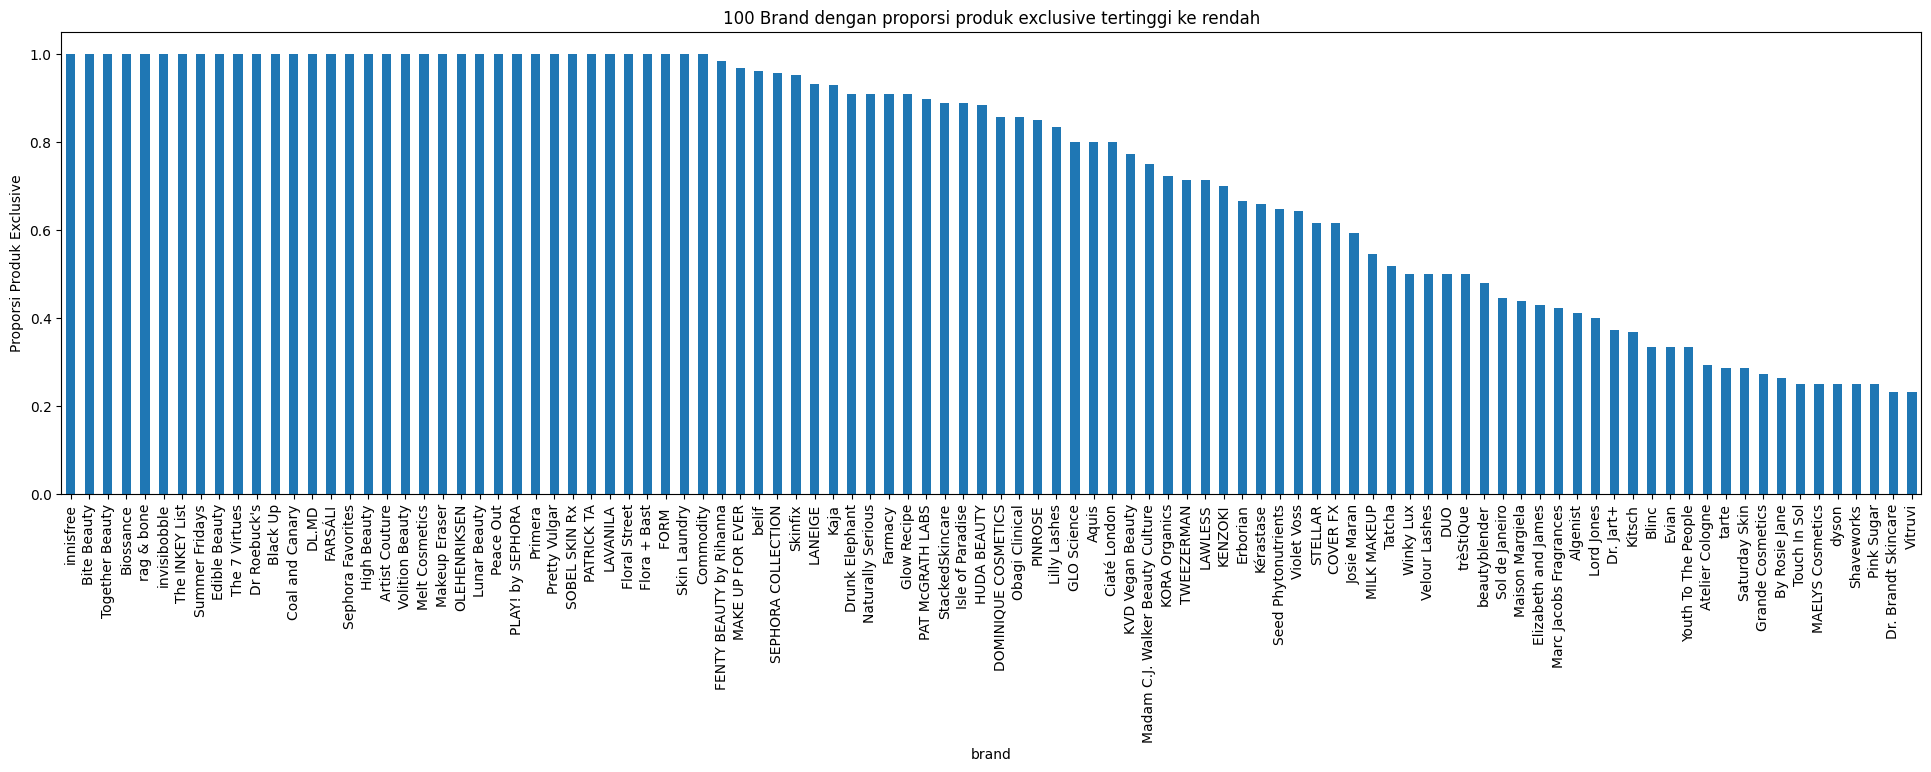

Gambar di atas menunjukkan 100 brand dengan proporsi produk exclusive tertinggi hingga terendah.

Dari visualisasi dapat dilihat bahwa terdapat sejumlah brand yang seluruh produknya berstatus exclusive (proporsi = 1), seperti Innisfree, Bite Beauty, Together Beauty, dan beberapa brand lainnya. Artinya, semua produk yang tercatat dari brand-brand ini dalam dataset merupakan produk exclusive.

Sementara itu, terdapat pula brand-brand yang memiliki proporsi produk exclusive mendekati 0.5, seperti trèStiQue, yang berarti separuh dari produk mereka exclusive dan separuh lainnya tidak. Pada bagian kanan grafik, terdapat brand-brand dengan proporsi produk exclusive di bawah 0.3 bahkan hingga sekitar 0.2, seperti Virtuvi, Dr. Brandt Skincare, dan Sugar.

Temuan ini mengindikasikan bahwa fitur brand sangat informatif dalam memprediksi status exclusive. Beberapa brand memang secara eksklusif memasarkan produk exclusive saja, sementara yang lain lebih banyak memasarkan produk non-exclusive. Pola ini sangat penting untuk dipertimbangkan dalam proses feature engineering dan pembuatan model klasifikasi, karena model dapat memanfaatkan informasi brand untuk meningkatkan akurasi klasifikasi status exclusive.


Selain brand, fitur dengan tipe kategorikal lainnya seperti category juga akan dianalisa

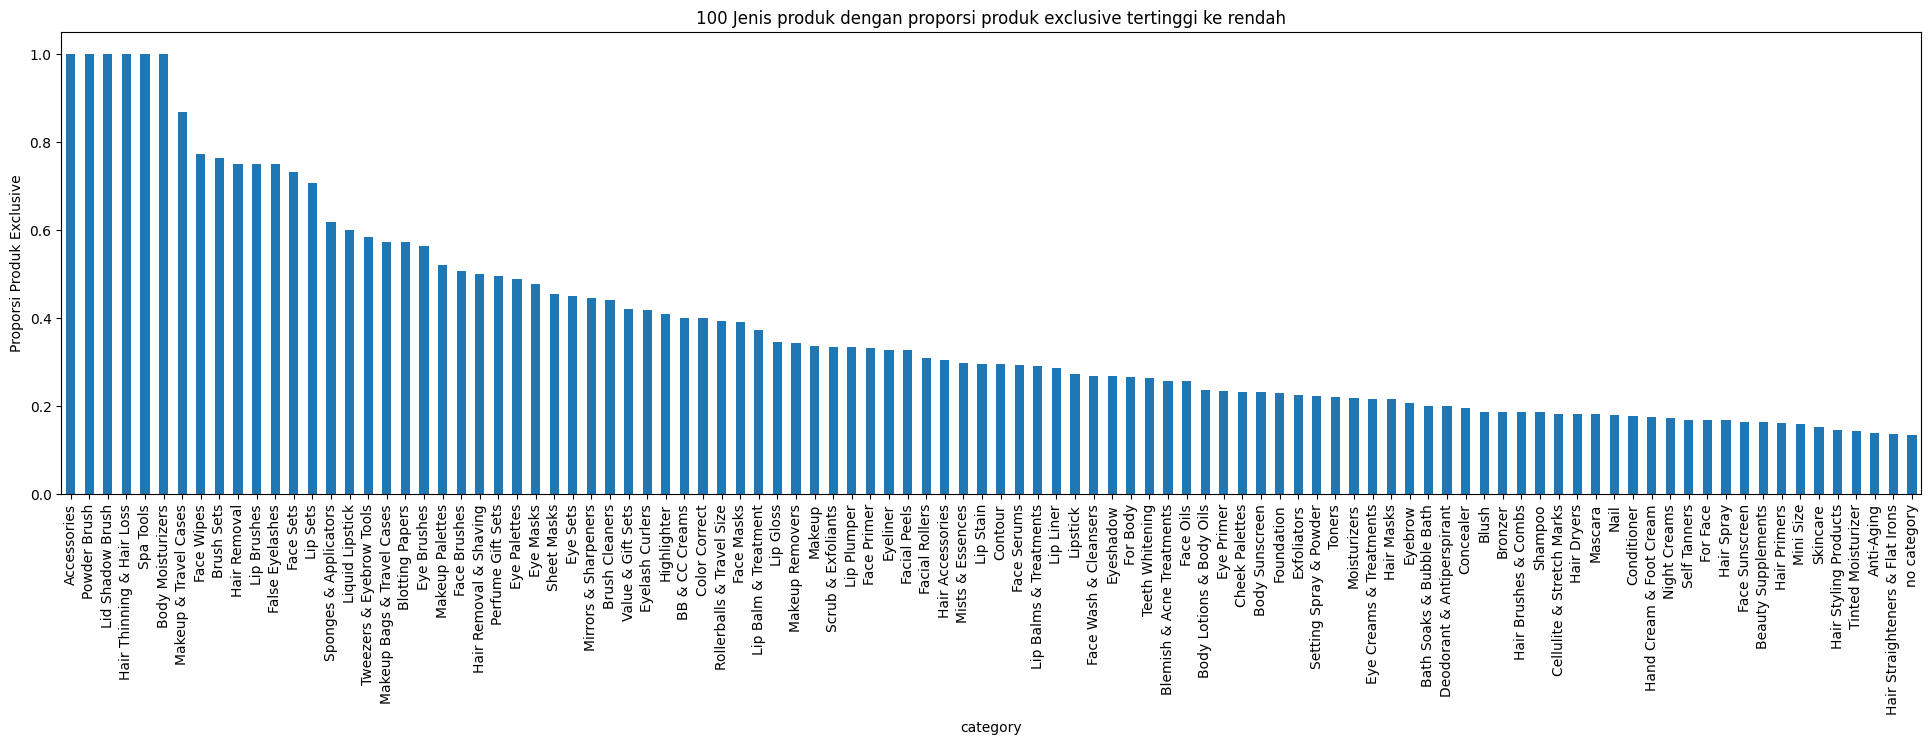

Dari grafik di atas, terlihat kategori "Accessories" memiliki proporsi produk exclusive sebesar 100%. Artinya, setiap produk pada kategori ini di dataset merupakan produk exclusive. Selain itu, beberapa kategori lain seperti "Powder Brush", "Lid Shadow Brush", dan "Hair Tinning Brush" juga memiliki proporsi produk exclusive 100%.

Sebaliknya, terdapat kategori dengan proporsi produk exclusive yang jauh lebih rendah (misal di bawah 20%), menandakan bahwa produk pada kategori-kategori tersebut hampir seluruhnya adalah non-exclusive.

Temuan ini sangat gemeter, karena berarti produk aksesoris, hairloss, powderbrush,dll yang memiliki proporsi 100% tidak mempunyai produk yang dijual secara umum, sangat elite dan mahal

Pola ini sangat penting dalam analisis dan pembuatan model, karena kategori produk ternyata sangat menentukan kemungkinan sebuah produk berstatus exclusive. Model klasifikasi yang menggunakan fitur kategori dengan tepat akan dapat meningkatkan akurasi klasifikasi status exclusive.
 

---

## 4. Data Cleansing (40 poin)

Lakukan pembersihan data, sesuai yang diajarkan di kelas, seperti:
- a. Handle missing values
- b. Handle duplicate data
- c. Handle outliers
- d. Feature transformation
- e. Feature encoding
- f. Handle class imbalance

Di laporan homework, tuliskan apa saja yang telah dilakukan dan metode yang digunakan.

 Tetap tuliskan jika memang ada tidak yang perlu di-handle (contoh: “Tidak perlu feature encoding karena semua feature sudah numerical” atau “Outlier tidak di-handle karena akan fokus menggunakan model yang robust terhadap outlier”).

In [26]:
agung.isnull().sum()

id                    0
brand                 0
category             13
rating               95
number_of_reviews     9
love                 34
price                 8
value_price          17
exclusive             0
dtype: int64

In [27]:
agung_total = agung.size
agung_null = agung.isnull().sum().sum()
agung_null_percentage = (agung_null / agung_total) * 100
print(f'Total data: {agung_total}')
print(f'Total missing values: {agung_null}')
print(f'Persentase missing values: {agung_null_percentage:.2f}%')

Total data: 72000
Total missing values: 176
Persentase missing values: 0.24%


In [28]:
gemeter = agung.dropna()

In [29]:
gemeter.isnull().sum()

id                   0
brand                0
category             0
rating               0
number_of_reviews    0
love                 0
price                0
value_price          0
exclusive            0
dtype: int64

In [30]:
gemeter.duplicated().sum()

np.int64(0)

In [31]:
gemeter = agung.dropna().copy()  
excluded_cols = ['id', 'rating', 'exclusive']
numeric_cols = gemeter.select_dtypes(include=['float64', 'int64']).columns
log_cols = [col for col in numeric_cols if col not in excluded_cols]

for col in log_cols:
    gemeter[f'{col}_log'] = np.log1p(gemeter[col])


In [32]:
gemeter.head()

,id,brand,category,rating,number_of_reviews,love,price,value_price,exclusive,number_of_reviews_log,love_log,price_log,value_price_log
0,50,SEPHORA COLLECTION,no category,5.0,46.0,0.0,50.0,50.0,0,3.850148,0.0,3.931826,3.931826
1,304,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0,0.000000,0.0,3.931826,3.931826
2,404,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0,0.000000,0.0,3.931826,3.931826
3,443,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0,0.000000,0.0,3.931826,3.931826
4,463,SEPHORA COLLECTION,no category,0.0,0.0,0.0,50.0,50.0,0,0.000000,0.0,3.931826,3.931826


In [33]:
gemeter.describe()

,id,rating,number_of_reviews,love,price,value_price,exclusive,number_of_reviews_log,love_log,price_log,value_price_log
count,7.828000e+03,7828.000000,7828.000000,7.828000e+03,7828.000000,7828.000000,7828.000000,7828.000000,7828.000000,7828.000000,7828.000000
mean,1.921029e+06,4.083866,301.762775,1.752500e+04,49.796917,50.984182,0.259964,4.077488,8.505652,3.650372,3.666611
std,3.759783e+05,0.760909,935.028844,4.445544e+04,46.803933,48.440669,0.438643,1.860712,1.887311,0.716864,0.726207
min,5.000000e+01,0.000000,0.000000,0.000000e+00,2.000000,2.000000,0.000000,0.000000,0.000000,1.098612,1.098612
25%,1.787153e+06,4.000000,14.000000,2.000000e+03,24.000000,24.000000,0.000000,2.708050,7.601402,3.218876,3.218876
50%,2.032803e+06,4.000000,55.000000,5.400000e+03,35.000000,35.000000,0.000000,4.025352,8.594339,3.583519,3.583519
75%,2.186629e+06,4.500000,229.000000,1.530000e+04,58.000000,60.000000,1.000000,5.438079,9.635673,4.077537,4.110874
max,2.293801e+06,5.000000,19000.000000,1.300000e+06,549.000000,549.000000,1.000000,9.852247,14.077876,6.309918,6.309918


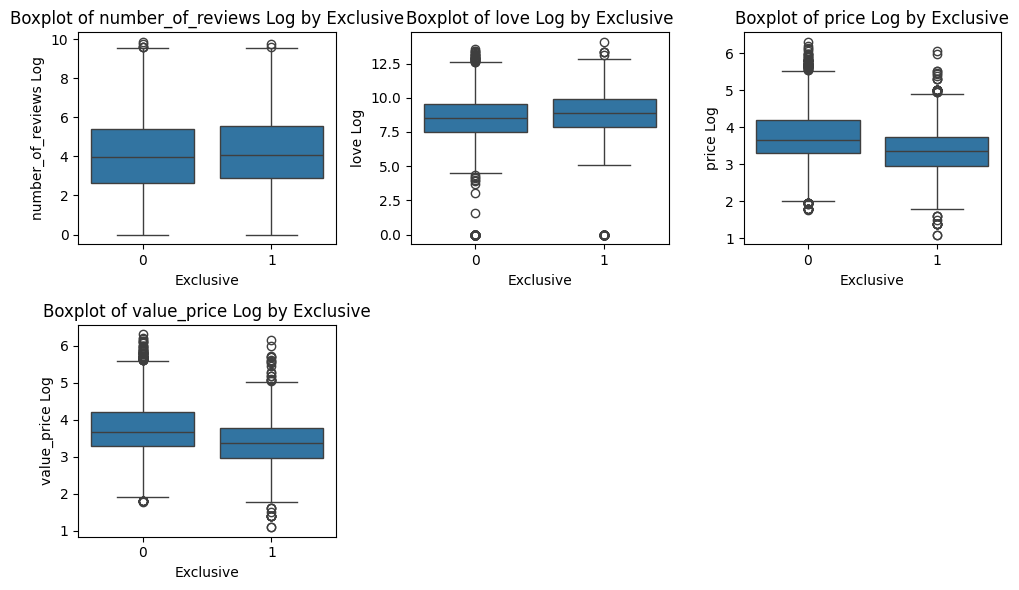

In [34]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(log_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='exclusive', y=f'{col}_log', data=gemeter)
    plt.title(f'Boxplot of {col} Log by Exclusive')
    plt.xlabel('Exclusive')
    plt.ylabel(f'{col} Log')
plt.tight_layout()
plt.show()

In [35]:
#karena distribusi sudah normal bisa menggunakan zscore untuk deteksi outlier
from scipy import stats
z_scores = stats.zscore(gemeter[log_cols])
outliers = np.abs(z_scores) > 3
outlier_indices = np.where(outliers.any(axis=1))[0]
print(f'Jumlah outlier: {len(outlier_indices)}')

Jumlah outlier: 365


In [36]:
#membuat dataframe baru yang bebas dari outlier berdasarkan zscore sebelumnya
mask = ~(outliers.any(axis=1))
gemeter_no_outlier = gemeter[mask]

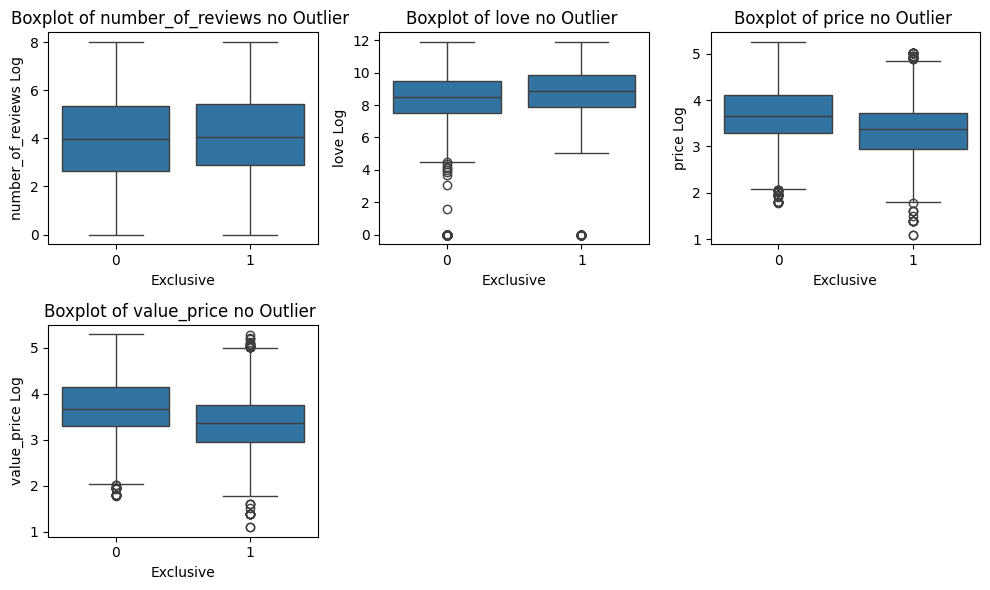

In [37]:
#boxplot setelah menghapus outlier
plt.figure(figsize=(10, 6))
for i, col in enumerate(log_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='exclusive', y=f'{col}_log', data=gemeter_no_outlier)
    plt.title(f'Boxplot of {col} no Outlier ')
    plt.xlabel('Exclusive')
    plt.ylabel(f'{col} Log')
plt.tight_layout()
plt.show()

In [38]:

# Pilih ulang kolom *_log* saja (hasil transformasi log)
log_cols = [col for col in gemeter_no_outlier.columns if col.endswith('_log')]

scaler = StandardScaler()
gemeter_no_outlier_scaled = gemeter_no_outlier.copy()  # Buat salinan untuk hasil scaling
gemeter_no_outlier_scaled[log_cols] = scaler.fit_transform(gemeter_no_outlier[log_cols])

# Cek hasil standarisasi kolom *_log*
print(gemeter_no_outlier_scaled[log_cols].head())


   number_of_reviews_log  love_log  price_log  value_price_log
0              -0.099590 -4.609018   0.491938         0.461688
1              -2.275128 -4.609018   0.491938         0.461688
2              -2.275128 -4.609018   0.491938         0.461688
3              -2.275128 -4.609018   0.491938         0.461688
4              -2.275128 -4.609018   0.491938         0.461688


In [40]:
gemeter_no_outlier_scaled.describe()

,id,rating,number_of_reviews,love,price,value_price,exclusive,number_of_reviews_log,love_log,price_log,value_price_log
count,7.463000e+03,7463.000000,7463.000000,7463.000000,7463.000000,7463.000000,7463.000000,7.463000e+03,7.463000e+03,7.463000e+03,7.463000e+03
mean,1.922835e+06,4.078856,210.917727,13102.958060,44.800371,45.799421,0.264907,-1.980342e-16,9.140038e-17,-2.056509e-16,1.980342e-16
std,3.763401e+05,0.760378,390.327516,20323.942029,32.651687,33.760400,0.441313,1.000067e+00,1.000067e+00,1.000067e+00,1.000067e+00
min,5.000000e+01,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,-2.275128e+00,-4.609018e+00,-3.796133e+00,-3.769313e+00
25%,1.790157e+06,4.000000,14.000000,2000.000000,24.000000,24.000000,0.000000,-7.449355e-01,-4.620558e-01,-5.871120e-01,-6.030013e-01
50%,2.035111e+06,4.000000,54.000000,5300.000000,34.000000,34.000000,0.000000,-1.077142e-02,6.944756e-02,-7.786089e-02,-1.005278e-01
75%,2.187136e+06,4.500000,214.000000,14600.000000,55.000000,58.000000,1.000000,7.595684e-01,6.221981e-01,6.334901e-01,6.792878e-01
max,2.293801e+06,5.000000,3000.000000,147100.000000,190.000000,196.000000,1.000000,2.249084e+00,1.882440e+00,2.490437e+00,2.479779e+00


In [41]:
gemeter_no_outlier_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7463 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     7463 non-null   int64  
 1   brand                  7463 non-null   object 
 2   category               7463 non-null   object 
 3   rating                 7463 non-null   float64
 4   number_of_reviews      7463 non-null   float64
 5   love                   7463 non-null   float64
 6   price                  7463 non-null   float64
 7   value_price            7463 non-null   float64
 8   exclusive              7463 non-null   int64  
 9   number_of_reviews_log  7463 non-null   float64
 10  love_log               7463 non-null   float64
 11  price_log              7463 non-null   float64
 12  value_price_log        7463 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 816.3+ KB


In [42]:
cols_to_drop = ['id', 'number_of_reviews', 'love', 'price', 'value_price', 'price_log']
agung_el_finale = gemeter_no_outlier_scaled.drop(cols_to_drop, axis=1)

In [52]:
print(agung_el_finale['exclusive'].value_counts())
print(agung_el_finale['exclusive'].value_counts(normalize=True))

exclusive
0    5486
1    1977
Name: count, dtype: int64
exclusive
0    0.735093
1    0.264907
Name: proportion, dtype: float64


Eksklusif = 0: 5486 data (≈ 73,5%)
Eksklusif = 1: 1977 data (≈ 26,5%)

In [43]:
agung_el_finale.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7463 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  7463 non-null   object 
 1   category               7463 non-null   object 
 2   rating                 7463 non-null   float64
 3   exclusive              7463 non-null   int64  
 4   number_of_reviews_log  7463 non-null   float64
 5   love_log               7463 non-null   float64
 6   value_price_log        7463 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 466.4+ KB


### Ringkasan Kolom:

Kategorikal:
- brand
- category

Numerik:
- rating
- number_of_reviews_log
- love_log
- value_price_log

Target:
- exclusive

In [44]:
from sklearn.model_selection import train_test_split

# Split data (jaga stratifikasi label!)
train, test = train_test_split(agung_el_finale, test_size=0.2, random_state=42, stratify=agung_el_finale['exclusive'])


In [45]:
for col in ['brand', 'category']:
    means = train.groupby(col)['exclusive'].mean()
    train[col + '_enc'] = train[col].map(means)
    test[col + '_enc'] = test[col].map(means)  
    
    # Jika ada kategori baru di test, isi dengan rata-rata global (opsional)
    test[col + '_enc'].fillna(means.mean(), inplace=True)

# Drop kolom aslinya
train = train.drop(['brand', 'category'], axis=1)
test = test.drop(['brand', 'category'], axis=1)

C:\Users\Wahgus\AppData\Local\Temp\ipykernel_28204\2543258137.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col + '_enc'].fillna(means.mean(), inplace=True)
C:\Users\Wahgus\AppData\Local\Temp\ipykernel_28204\2543258137.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [46]:
train.head()

,rating,exclusive,number_of_reviews_log,love_log,value_price_log,brand_enc,category_enc
7763,4.5,0,0.279923,-0.084044,-0.544431,0.209302,0.210938
4630,4.5,1,-0.674212,-0.070576,-0.381357,1.000000,0.203125
250,4.5,0,-0.010771,0.280225,0.955772,0.125000,0.523810
4977,5.0,1,-0.974045,0.765897,-0.863373,0.962025,0.245614
3505,3.0,0,0.186644,-0.141509,0.729071,0.111111,0.223077


In [47]:
test.head()

,rating,exclusive,number_of_reviews_log,love_log,value_price_log,brand_enc,category_enc
6063,4.0,1,-0.582380,-0.385844,-2.304584,0.954054,0.160000
5470,3.5,1,-0.783920,0.236564,1.482092,0.812500,0.378378
693,4.5,0,1.122941,0.109134,0.339713,0.027027,0.235294
5596,4.5,0,-1.033579,-0.172683,0.461688,0.000000,0.245614
4607,0.0,0,-2.275128,-4.609018,-1.523188,0.230769,0.222222


In [48]:

from sklearn.preprocessing import StandardScaler

scaler_rating = StandardScaler()
train['rating'] = scaler_rating.fit_transform(train[['rating']])
test['rating']  = scaler_rating.transform(test[['rating']])

print(train['rating'].head())

7763    0.559053
4630    0.559053
250     0.559053
4977    1.232217
3505   -1.460439
Name: rating, dtype: float64


In [50]:
print(train.head())

        rating  exclusive  number_of_reviews_log  love_log  value_price_log  \
7763  0.559053          0               0.279923 -0.084044        -0.544431   
4630  0.559053          1              -0.674212 -0.070576        -0.381357   
250   0.559053          0              -0.010771  0.280225         0.955772   
4977  1.232217          1              -0.974045  0.765897        -0.863373   
3505 -1.460439          0               0.186644 -0.141509         0.729071   

      brand_enc  category_enc  
7763   0.209302      0.210938  
4630   1.000000      0.203125  
250    0.125000      0.523810  
4977   0.962025      0.245614  
3505   0.111111      0.223077  


---

## *Interpretasi*

A. Handle Missing values
- saya sudah melakukan handle untuk missing values, pertama saya cek berapa jumlah missing values dan mendapatkan bahwa 176 data merupakan missing values (0.24%), karena missing valuenya hanya dikisaran 0.24% yang berarti cukup kecil jika dibandingkan dengan populasi data, maka saya memutuskan untuk membuang data missing values tersebut.

B. Handle Duplicate Data
- Saya sudah cek apakah ada data duplikat atau tidak. saya mendapatkan output np.int64(0) berarti tidak ada data duplikat yang perlu di handle.

C. Handle Outlier
- Karena dari nomer 2 saya sudah mengetahui bahwa tipe distribusinya skewed", saya langsung berpikir untuk menggunakan transform log untuk mendapatkan distribusi yang lebih normal. Setelah saya lakukan saya mendapatkan fitur baru yaitu fitur yang berisi nilai setelah proses transform log, fitur barunya yang isi _log dibelakangnya.

Berikut merupakan boxplotnya yang sudah dilakukan transformasi log

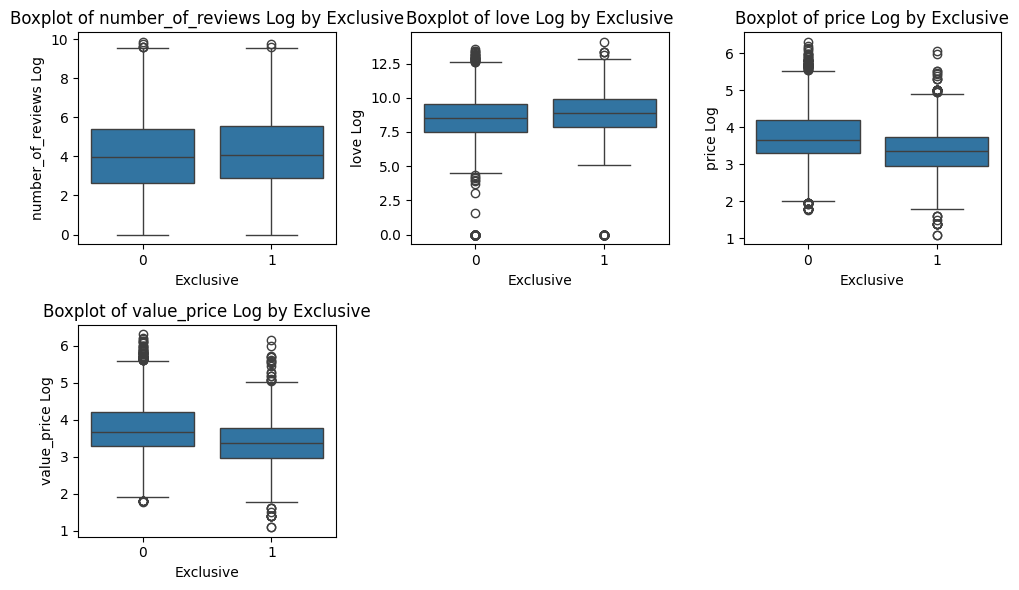

Dapat dilihat bahwa distribusinya sudah cukup ketengah dan tidak seekstrim di nomer 2. dan karena di LMS diajarkan bahwa apabila kita mendapatkan tipe distribusinya normal maka menggunakan zscore merupakan metode yang paling efektif untuk membuang outlier. walaupun saya sempet coba IQR masih oke aja wkwkw

intinya dengan menggunakan zscore saya mendapatkan bahwa Jumlah outlier: 365. lalu saya bersihkan dan lakukan plot lagi

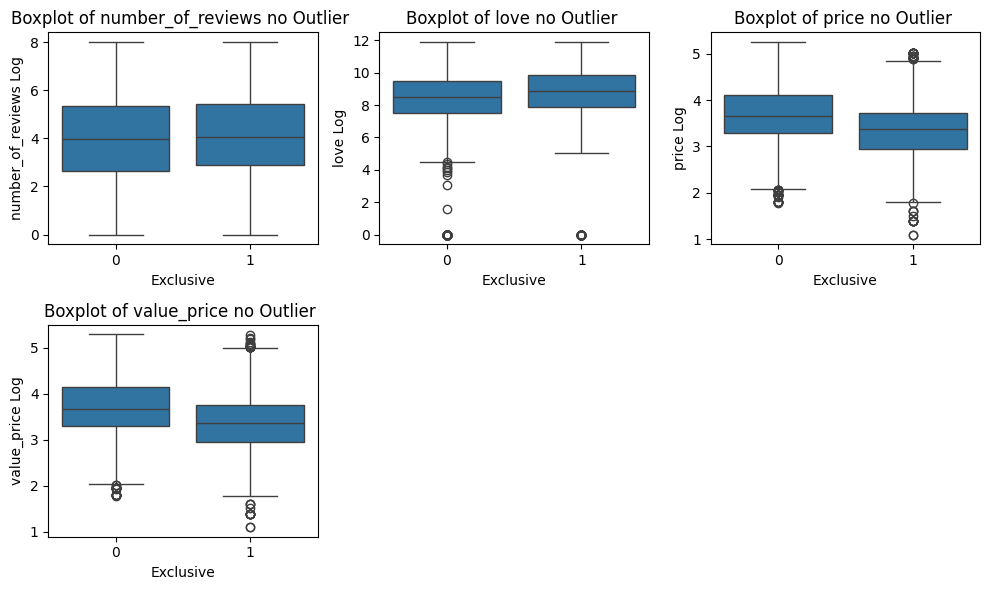

Disini bisa dilihat bahwa outlier sudah clean, dengan mengeliminasi outlier yang berada diluar batas outlier bound yang didapatkan pada process zscore.

D. Feature transformation
- Karena sudah saya lakukan transformasi log, selanjutnya saya melakukan standarisasi, disini standarisasi memastikan semua fitur numerik memiliki skala yang seragam sehingga tidak ada fitur yang mendominasi model. berikut adalah hasilnya

```
       rating  exclusive  number_of_reviews_log  love_log  value_price_log  brand_enc  category_enc
7763  0.559053          0               0.279923 -0.084044        -0.544431   0.209302      0.210938  
4630  0.559053          1              -0.674212 -0.070576        -0.381357   1.000000      0.203125 
250   0.559053          0              -0.010771  0.280225         0.955772   0.125000      0.523810  
4977  1.232217          1              -0.974045  0.765897        -0.863373   0.962025      0.245614 
3505 -1.460439          0               0.186644 -0.141509         0.729071   0.111111      0.223077

```

sudah rapi dan siap di train data diatas merupakan data train yang sudah saya encoding juga untuk fitur kategoriknya. sehingga ini juga menjawab sub soal E.

E. Feature encoding

Sudah dijawab di sub soal D. dimana saya juga sudah melakukan fitur encoding menggunakan mean encoding. namun ada tahapan yang saya lakukan sebelum melakukan mean encoding tersebut. yang pertama saya split dulu datasetnya menjadi train dan testing, baru melakukan encoding hal ini untuk bertujuan untuk menghindari Data leakage

F. Class imbalance

tidak ada imbalance extreme masih cukup wajar sehingga tidak perlu handling

exclusive
0    5486
1    1977
Name: count, dtype: int64
exclusive
0    0.735093
1    0.264907
Name: proportion, dtype: float64

---

## `5. Feature Engineering (30 poin)`

Cek feature yang ada sekarang, lalu lakukan:
- a. Feature selection (membuang feature yang kurang relevan atau redundan)
- b. Feature extraction (membuat feature baru dari feature yang sudah ada)
- c. Tuliskan minimal 4 feature tambahan (selain yang sudah tersedia di dataset) yang mungkin akan sangat membantu membuat performansi model semakin bagus (ini hanya ide saja, untuk menguji kreativitas teman-teman, tidak perlu benar-benar dicari datanya dan tidak perlu diimplementasikan)

Untuk 5A & 5B, tetap tuliskan jika memang tidak bisa dilakukan (contoh: “Semua feature digunakan untuk modelling (tidak ada yang dihapus), karena semua feature relevan”)


---

## Interpretasi
- A. Sudah saya lakukan di nomer 4
- B. Pada tahap ini, tidak dilakukan feature extraction (pembuatan fitur baru dari fitur yang sudah ada), karena seluruh fitur yang digunakan sudah cukup representatif untuk kasus prediksi ini. Namun, proses encoding dilakukan pada fitur kategorikal (brand dan category) menggunakan mean encoding agar fitur tersebut dapat digunakan sebagai fitur numerik oleh model. Semua keputusan tersebut sudah didasarkan oleh interpretasi pada semua nomer sebelumnya 1-4 ini sudah sangat clean dan gacor menurut saya
- C. Setelah saya menjawab semua soal diatas saya jadi gemes ingin menambahkan fitur fitur ini : 

1. Reputasi Brand
Skor reputasi brand berdasarkan review agregat di luar dataset ini (misal dari rating Google atau dari survey) karena menurut saya ini bisa jadi fitur numerik tambahan yang sangat kuat.

2. Stock Availability
stok merupakan satu indikator bahwa produk tersebut laku, atau produksinya terbatas. Dengan fitur ini kita dapat mengetahui banyak hal terkait produk yang dijual dan saya merasa bahwa menambahkan fitur stok bisa memiliki korelasi yang besar untuk label target exclusive. Selain itu ini memungkinkan adanya label target lain seperti prediksi stok dll.

3. Discount Percentage
Presentase diskon tentu penting dalam dataset ini, karena terdapat 2 fitur yang memiliki nilai ambigu di dataset ini. saat saya melihat price dan value_price saya langsung sadar bahwa salah satunya pasti adalah data harga yang setelah dikenakan diskon. saya berharap mengetahui diskon tersebut, walaupun saya belum tahu apakah data tersebut akan berkorelasi atau tidak dengan label target yaitu exclusive.

2. Status afiliasi brand
Apakah brand termasuk "official partner" atau "brand partner" utama dari toko online ini. saya kurang paham dataset yang diberikan ini ecommerce atau toko offline, saya berasumsi bahwa ini merupakan ecommerce, dan melihat trend tiktok besarnya pengaruh afiliasi brand terhadap exclusivitas, harga maupun review ini bisa jadi fitur yang sangat bisa melengkapi dataset ini. Dan saya berharap mendapatkan link kaggle dari dataset ini
